## Load in Test Case & Run Power Flow

In [14]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets
disturbance_profile_dir = project_dir / "disturbance_profiles" # disturbance profiles for ANDES perturbation
out_dir = project_dir / "out"

In [15]:
# setting up ANDES
%matplotlib inline

from calculate_metrics import calculate_metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import andes

andes.config_logger(stream_level=30)

In [16]:
# import case file
case_path = andes.get_case(test_case_dir / "regf2_testbench.xlsx")
STEP_TIME = 0.01 # 10 ms

## Run TDS & Initial Results

In [21]:
ss = andes.load(case_path, setup=False)
ss.REGF2.set("Tr",1,0.005)
ss.REGF2.set("mf",1,5)

print(ss.REGF2.Tr.v)

ss.setup()
ss.config.warn_abnormal = 0
ss.PFlow.run()

ss.TDS.config.tf = 20 # Baruzzi et al ran simulation for 9s after disturbance
ss.TDS.config.fixt = 1 # fixed step size
ss.TDS.config.tstep = STEP_TIME # matches Baruzzi et al. 

ss.TDS.config.no_tqdm = 1
ss.TDS.config.criteria = 1
ss.TDS.run()

[0.005]


True

## Metrics/Analysis

## Record Metrics

In [22]:
# anything w/o units is in p.u. 
metrics_df = pd.DataFrame({
    "Tr (s)": [], 
    "Pref": [],
    "Peak Inertial Power": [],
    "Power Available":[],
    "H_RMSE (s)": [],
    "Max RoCoF":[],
    "Nadir":[],
})
metrics_df

,Tr (s),Pref,Peak Inertial Power,Power Available,H_RMSE (s),Max RoCoF,Nadir


In [23]:
metrics_df, h_series = calculate_metrics(ss, True)
metrics_df

,Tr (s),Pref,Peak Inertial Power,Power Available,M_RMSE (s),Max RoCoF,Nadir
0,0.005,0.2,1.27845,1.5,6.313284,0.043385,0.937767


,0.005
5.200100,12.482221
5.200200,12.472759
5.210200,11.527415
5.220200,10.759067
5.230200,10.171080
...,...
5.966867,14.214377
5.976867,14.373930
5.986867,14.532675
5.996867,14.697783


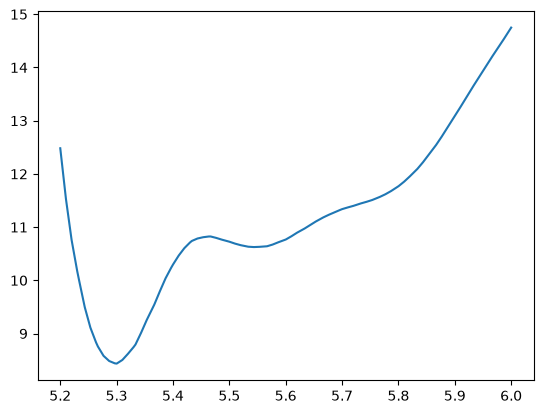

In [24]:
plt.plot(h_series.index, h_series)
h_series